# Libraries

In [1]:
import warnings
from pathlib import Path

from tqdm import tqdm

from matplotlib import pyplot as plt
import numpy as np
import seaborn as sn
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
import shap
from boruta import BorutaPy
import neurokit2 as nk
from helper_code import *

d:\Coding\GitHub\ECG-Chagas\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Settings

In [2]:
%load_ext autoreload

%autoreload 2

# Control figure size
%matplotlib inline
figsize=(14, 4)

warnings.filterwarnings('ignore')

# Detection of Chagas Disease from the ECG: PhysioNet Challenge 2025

## Introduction

Chagas disease is a potentially life-threatening illness caused by the protozoan parasite Trypanosoma cruzi (T. cruzi). It is found mainly in endemic areas of 21 countries in Latin America, where it is mostly transmitted to humans by the feces of triatomine bugs known as "kissing bugs". The disease is also known as American trypanosomiasis.

The disease is named after the Brazilian physician Carlos Chagas, who discovered it in 1909. The disease can be acute or chronic, but the chronic form is the most common and usually develops 10 to 30 years after the initial infection. The acute phase of the disease is usually mild or asymptomatic, but the chronic phase can cause serious heart and digestive problems.

The disease is diagnosed by detecting the parasite in the blood or by serological tests. The electrocardiogram (ECG) is an important tool for diagnosing Chagas disease, as it can show changes in the heart's electrical activity that are characteristic of the disease.

The goal of this challenge is to develop algorithms that can automatically detect Chagas disease from ECG signals. The challenge is based on a dataset of ECG signals from patients with Chagas disease and healthy controls. The dataset is provided by the PhysioNet Challenge 2025.

## EDA

In [3]:
exams = pd.read_csv('code15_hdf5/exams.csv')

In [4]:
train_data_folder = Path("code15_wfdb")
holdout_data_folder = Path("holdout_data")

train_records = find_records(train_data_folder.absolute().__str__())
holdout_records = find_records(holdout_data_folder.absolute().__str__())

all_records = train_records + holdout_records

In [5]:
def get_random_patient(random: bool = True, with_disease=True):
    if random:
        random_id = np.random.randint(0, len(train_records))
    else:
        random_id = 34
    record = str(train_data_folder.absolute()) + "/" + train_records[random_id]
    header = load_header(record)
    signals, fields = load_signals(record)
    frequency = get_sampling_frequency(header)
    label = get_label(header)

    if label == 0 and with_disease:
        return get_random_patient(with_disease)
    elif label == 1 and not with_disease:
        return get_random_patient(with_disease)
    else:
        return record, train_records[random_id], label, signals, frequency

In [6]:
record, exam_id, label, signals, frequency = get_random_patient(random=False, with_disease=False)
print(f"Record: {record}, Exam ID: {exam_id}, Label: {label}")
exams[exams['exam_id'] == int(exam_id)]

Record: d:\Coding\GitHub\ECG-Chagas\code15_wfdb/1004472, Exam ID: 1004472, Label: 0


,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file
62303,1004472,47,False,64.128204,False,False,False,False,False,False,415499,False,2.424656,False,exams_part0.hdf5


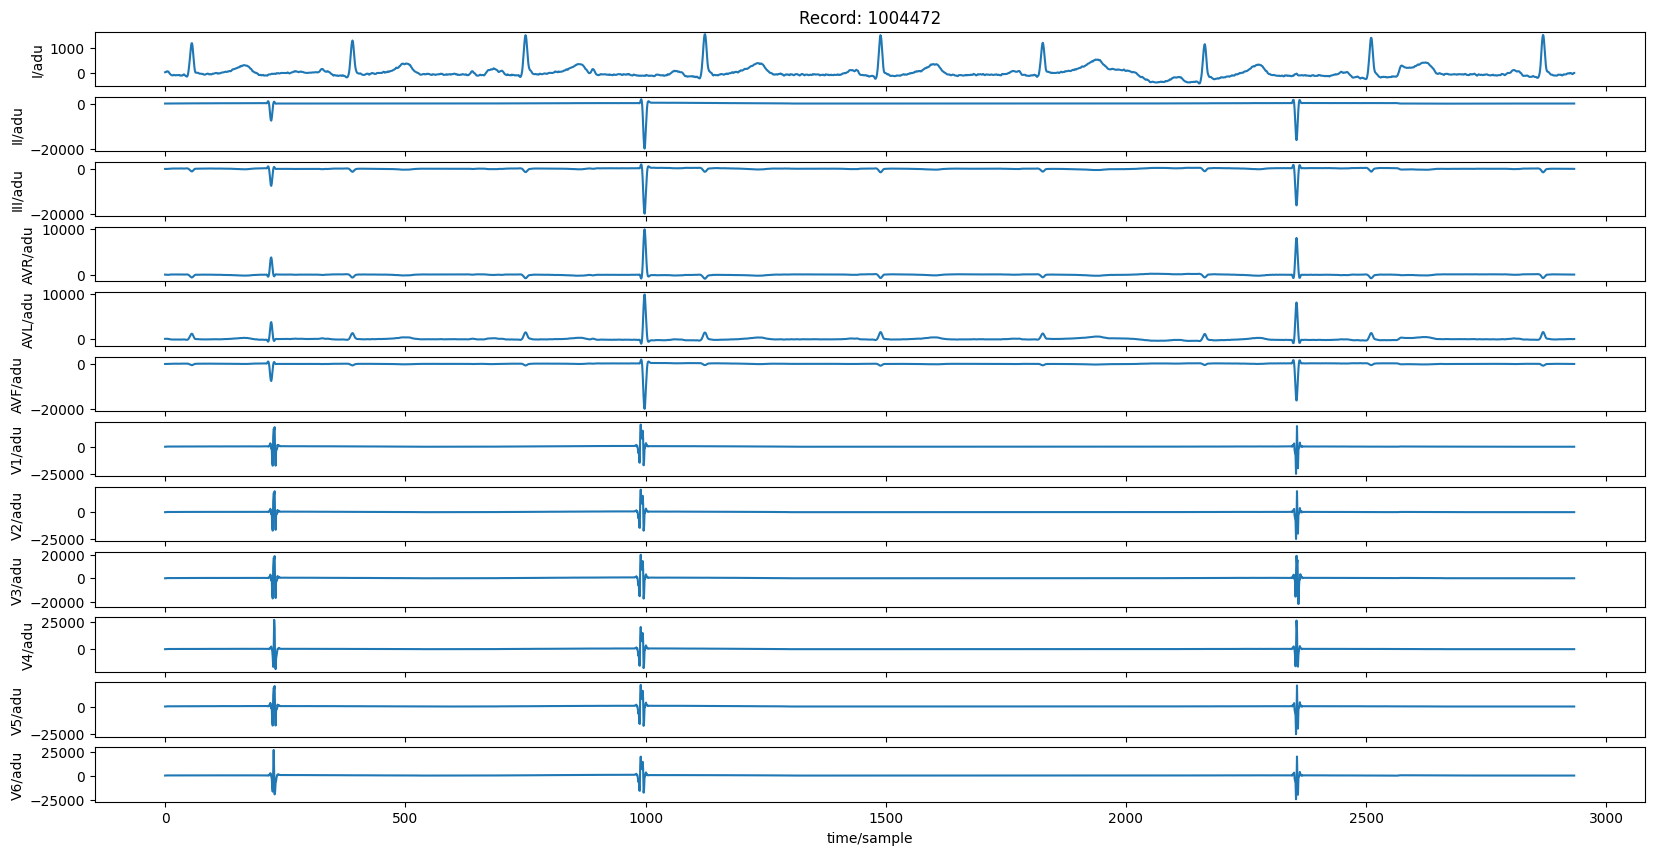

In [7]:
wfdb.plot_wfdb(record=wfdb.rdrecord(record, physical=False), figsize=(20, 10), time_units='samples')

---

In [8]:
# Define a new function
def my_processing(ecg_signals: np.ndarray, channel: int, frequency: int):
    # Do processing
    ecg_cleaned = nk.ecg_clean(ecg_signals[:, channel], sampling_rate=frequency, method="biosppy")
    peaks, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=frequency)
    hrv_time = nk.hrv_time(peaks, sampling_rate=frequency, show=False)
    waves, waves_signals = nk.ecg_delineate(ecg_cleaned, info, sampling_rate=frequency, method="dwt", check=True, show=False, show_type='all')

    phases = nk.ecg_phase(ecg_cleaned, peaks, sampling_rate=frequency, delineate_info=waves_signals)
    rate = nk.ecg_rate(info, sampling_rate=frequency, desired_length=len(ecg_cleaned))
    quality = nk.ecg_quality(ecg_cleaned, sampling_rate=frequency)

    # Prepare output
    signals = pd.DataFrame({"ECG_Raw": ecg_signals[:, channel],
                            "ECG_Clean": ecg_cleaned,
                            "ECG_Rate": rate,
                            "ECG_Quality": quality})
    signals = pd.concat([signals, peaks, waves, phases], axis=1)

    # Create info dict
    info = info
    info["sampling_rate"] = frequency

    waves_signals['ECG_R_Peaks'] = info['ECG_R_Peaks']
    
    return signals, info, waves_signals

In [9]:
processed_signals, info, waves_signals = my_processing(signals, 0, frequency)

In [10]:
def check_interval(waves_signals):
    df_waves = pd.DataFrame(waves_signals)
    df_waves.drop(columns=['ECG_R_Onsets', 'ECG_R_Offsets'], inplace=True)
    correct_indices = ['ECG_P_Onsets', 'ECG_P_Peaks', 'ECG_P_Offsets',
       'ECG_Q_Peaks', 'ECG_R_Peaks', 'ECG_S_Peaks', 'ECG_T_Onsets', 'ECG_T_Peaks', 'ECG_T_Offsets', ]
    rows = df_waves.shape[0]
    mask = np.zeros(rows)
    for i in range(1, rows):
        start_interval = df_waves.loc[i-1, 'ECG_R_Peaks']
        end_interval = df_waves.loc[i, 'ECG_R_Peaks']
        sliced_df = df_waves[df_waves.isin([start_interval, end_interval]).any(axis=1)]
        # if the sliced df has no missing values, then the interval is correct and the mask should be 1
        first_condition = sliced_df[correct_indices].isnull().sum().sum() == 0
        second_condition = correct_indices == sliced_df.iloc[0].sort_values(ascending=True).index.tolist()
        if first_condition and second_condition:
            mask[i] = 1
    return df_waves[mask == 1]

In [11]:
def ecg_signal_features(row, frequency: int = 400):
    ECG_P_Peaks, ECG_P_Onsets, ECG_P_Offsets, ECG_Q_Peaks, ECG_S_Peaks, ECG_T_Peaks, ECG_T_Onsets, ECG_T_Offsets, ECG_R_Peaks = row
    # Compute the P wave duration
    P_wave_duration = (ECG_P_Offsets - ECG_P_Onsets) / frequency
    # Compute the PR interval
    PR_interval = (ECG_Q_Peaks - ECG_P_Onsets) / frequency
    # Compute the PR segment
    PR_segment = (ECG_Q_Peaks - ECG_P_Offsets) / frequency
    # Compute the QRS duration
    QRS_duration = (ECG_S_Peaks - ECG_Q_Peaks) / frequency
    # Compute the QT interval
    QT_interval = (ECG_T_Offsets - ECG_Q_Peaks) / frequency
    # Compute the ST segment
    ST_segment = (ECG_T_Onsets - ECG_S_Peaks) / frequency

    return {
        "P_wave_duration": P_wave_duration,
        "PR_interval": PR_interval,
        "PR_segment": PR_segment,
        "QRS_duration": QRS_duration,
        "QT_interval": QT_interval,
        "ST_segment": ST_segment
    }

In [12]:
def st_slope(signal_df, s_peak, t_onset):
    return (signal_df.iloc[t_onset]['ECG_Clean'] - signal_df.iloc[s_peak]['ECG_Clean']) / (t_onset - s_peak)

In [13]:
correct_waves = check_interval(waves_signals)

In [14]:
correct_waves[["P_wave_duration","PR_interval","PR_segment","QRS_duration","QT_interval","ST_segment"]] = correct_waves.apply(lambda x: ecg_signal_features(x, frequency), axis=1, result_type='expand')

In [15]:
correct_waves['ST_slope'] = correct_waves.apply(lambda x: st_slope(processed_signals, int(x['ECG_S_Peaks']), int(x['ECG_T_Onsets'])), axis=1)

In [16]:
correct_waves

,ECG_P_Peaks,ECG_P_Onsets,ECG_P_Offsets,ECG_Q_Peaks,ECG_S_Peaks,ECG_T_Peaks,ECG_T_Onsets,ECG_T_Offsets,ECG_R_Peaks,P_wave_duration,PR_interval,PR_segment,QRS_duration,QT_interval,ST_segment,ST_slope
1,684,662,694,740.0,776.0,862.0,846.0,882.0,750,0.0800,0.1950,0.1150,0.0900,0.3550,0.1750,0.004339
2,1061,1047,1086,1112.0,1149.0,1235.0,1212.0,1268.0,1124,0.0975,0.1625,0.0650,0.0925,0.3900,0.1575,0.004084
3,1428,1417,1434,1479.0,1515.0,1601.0,1587.0,1625.0,1489,0.0425,0.1550,0.1125,0.0900,0.3650,0.1800,0.004897
4,1765,1751,1771,1816.0,1852.0,1940.0,1913.0,1963.0,1827,0.0500,0.1625,0.1125,0.0900,0.3675,0.1525,0.004248
5,2110,2105,2124,2153.0,2182.0,2276.0,2243.0,2299.0,2164,0.0475,0.1200,0.0725,0.0725,0.3650,0.1525,0.003354
6,2448,2441,2453,2499.0,2545.0,2622.0,2598.0,2648.0,2510,0.0300,0.1450,0.1150,0.1150,0.3725,0.1325,0.007298


In [21]:
error_records = []
channel = 1
hand_features = pd.DataFrame()
for i in tqdm(range(len(train_records))):
    record = str(train_data_folder.absolute()) + "/" + train_records[i]
    header = load_header(record)
    signals, fields = load_signals(record)
    frequency = get_sampling_frequency(header)

    try:
        processed_signals, _, waves_signals = my_processing(signals, channel, frequency)
    except:
        error_records.append(train_records[i])
        continue
    correct_waves = check_interval(waves_signals)
    if correct_waves.shape[0] == 0:
        error_records.append(train_records[i])
        continue
    correct_waves[["P_wave_duration","PR_interval","PR_segment","QRS_duration","QT_interval","ST_segment"]] = correct_waves.apply(lambda x: ecg_signal_features(x, frequency), axis=1, result_type='expand')
    correct_waves['ST_slope'] = correct_waves.apply(lambda x: st_slope(processed_signals, int(x['ECG_S_Peaks']), int(x['ECG_T_Onsets'])), axis=1)
    correct_waves['record'] = train_records[i]
    hand_features = pd.concat([hand_features, correct_waves])

100%|██████████| 19901/19901 [1:23:18<00:00,  3.98it/s]


In [22]:
# save correct waves dataframe to a csv file
hand_features.to_csv('hand_features.csv', index=False)

# save error records to a csv file
pd.DataFrame(error_records).to_csv('error_records.csv', index=False)

---

In [19]:
df = pd.read_csv("data/data.csv", encoding='utf-8')

In [20]:
df.head()

,exam_id,age,nn_predicted_age,sex,mean_DI,std_DI,mean_DII,std_DII,mean_DIII,std_DIII,...,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,normal_ecg,label
0,1000010,40,37.822990,Female,-0.450692,0.222797,-0.864404,0.273517,-0.413709,0.194939,...,False,False,False,False,False,False,415630,0,True,0
1,1000078,56,44.491043,Male,-0.313750,0.347462,-1.692581,0.560666,-1.378823,0.339585,...,False,False,False,False,False,False,695177,0,False,0
2,1000087,72,75.249695,Male,1.079969,0.468575,2.401406,0.958448,1.321447,0.572557,...,False,False,False,False,False,False,1161144,0,False,0
3,1000182,33,28.969059,Female,0.002325,0.220697,0.003436,0.301733,0.001109,0.106127,...,False,False,False,False,False,False,966826,0,True,0
4,1000263,54,79.824660,Female,0.000717,0.176115,-0.002417,0.253241,-0.003094,0.329076,...,False,True,False,False,False,False,1509478,0,False,0


In [5]:
df['sex'] = df['sex'].apply(lambda x: 1 if x == 'M' else 0)
df['1dAVb'] = df['1dAVb'].apply(lambda x: 1 if x == True else 0)
df['RBBB'] = df['RBBB'].apply(lambda x: 1 if x == True else 0)
df['LBBB'] = df['LBBB'].apply(lambda x: 1 if x == True else 0)
df['SB'] = df['SB'].apply(lambda x: 1 if x == True else 0)
df['ST'] = df['ST'].apply(lambda x: 1 if x == True else 0)
df['AF'] = df['AF'].apply(lambda x: 1 if x == True else 0)
df['normal_ecg'] = df['normal_ecg'].apply(lambda x: 1 if x == True else 0)

In [6]:
df['nn_predicted_age'] = df['age'] - df['nn_predicted_age']
df.rename(columns={'nn_predicted_age': 'heart_age_discrepancy'}, inplace=True)

In [7]:
df.describe()

,exam_id,age,heart_age_discrepancy,sex,mean_DI,std_DI,mean_DII,std_DII,mean_DIII,std_DIII,...,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,normal_ecg,label
count,3.979800e+04,39798.000000,39798.000000,39798.0,39798.000000,39798.000000,39798.000000,39798.000000,39798.000000,39798.000000,...,39798.000000,39798.000000,39798.000000,39798.000000,39798.000000,39798.000000,3.979800e+04,39798.000000,39798.000000,39798.000000
mean,1.460541e+06,52.970024,-0.949555,0.0,0.027265,0.349579,-0.085853,0.416263,-0.113116,0.365916,...,0.017111,0.026961,0.017011,0.016383,0.021710,0.020277,7.933730e+05,0.026534,0.383813,0.020579
std,1.158977e+06,19.726332,11.004051,0.0,0.872341,0.496514,1.631345,0.507951,1.627405,0.549678,...,0.129688,0.161972,0.129313,0.126944,0.145736,0.140949,5.519819e+05,0.160719,0.486319,0.141972
min,1.400000e+01,17.000000,-70.459526,0.0,-12.776328,0.000000,-15.080458,0.000000,-15.270543,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+00,0.000000,0.000000,0.000000
25%,5.679458e+05,36.000000,-7.531614,0.0,-0.004926,0.195360,-0.117893,0.219191,-0.151299,0.146428,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.530472e+05,0.000000,0.000000,0.000000
50%,1.132691e+06,54.000000,-0.920599,0.0,0.001537,0.260882,0.000403,0.302144,-0.000923,0.227749,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.589030e+05,0.000000,0.000000,0.000000
75%,2.658224e+06,70.000000,5.939183,0.0,0.009679,0.358157,0.005815,0.432203,0.003755,0.380995,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.283076e+06,0.000000,1.000000,0.000000
max,4.416554e+06,91.000000,68.739881,0.0,16.219297,13.239260,18.044898,12.039916,17.027142,13.331735,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.773653e+06,1.000000,1.000000,1.000000


In [19]:
factor_cols = ['patient_id','exam_id']
num_cols = [c for c in df.columns[:-1] if df[c].nunique() > 2 and c not in factor_cols]
cat_cols = [c for c in df.columns[:-1] if df[c].nunique() == 2 and c not in factor_cols]
print(f'Numeric: {num_cols}\nTotal: {len(num_cols)}')
print(f'Categorical: {cat_cols}\nTotal: {len(cat_cols)}')

NameError: name 'df' is not defined

In [20]:
_, axes = plt.subplots(nrows=5, ncols=int(np.ceil(len(num_cols)//4)), figsize=(20, 10))
for ax, cname in zip(axes.ravel(), num_cols):
    df.hist(cname, ax=ax)
plt.tight_layout()
plt.show()

NameError: name 'num_cols' is not defined

In [21]:
_, axes = plt.subplots(nrows=2, ncols=int(np.ceil(len(cat_cols)//2)), figsize=(20, 10))
for ax, cname in zip(axes.ravel(), cat_cols):
    df.hist(cname, ax=ax, bins=2)
plt.tight_layout()

NameError: name 'cat_cols' is not defined

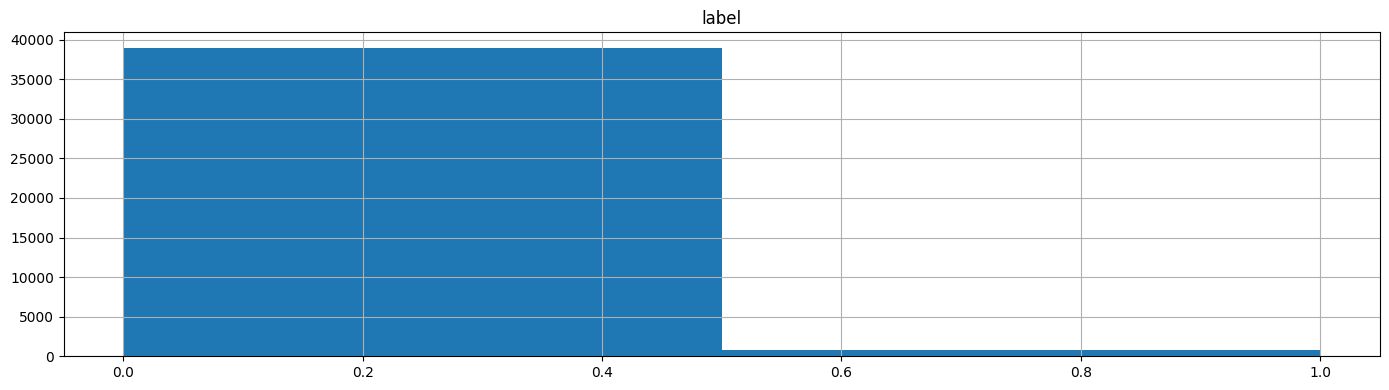

In [11]:
df.hist('label', bins=2, figsize=figsize)
plt.tight_layout()


In [22]:
_, axes = plt.subplots(nrows=2, ncols=int(np.ceil(len(cat_cols)//2)), figsize=figsize)
for ax, cname in zip(axes.ravel(), cat_cols):
    df.groupby(cname)['label'].mean().plot.bar(ax=ax)
plt.tight_layout()

NameError: name 'cat_cols' is not defined

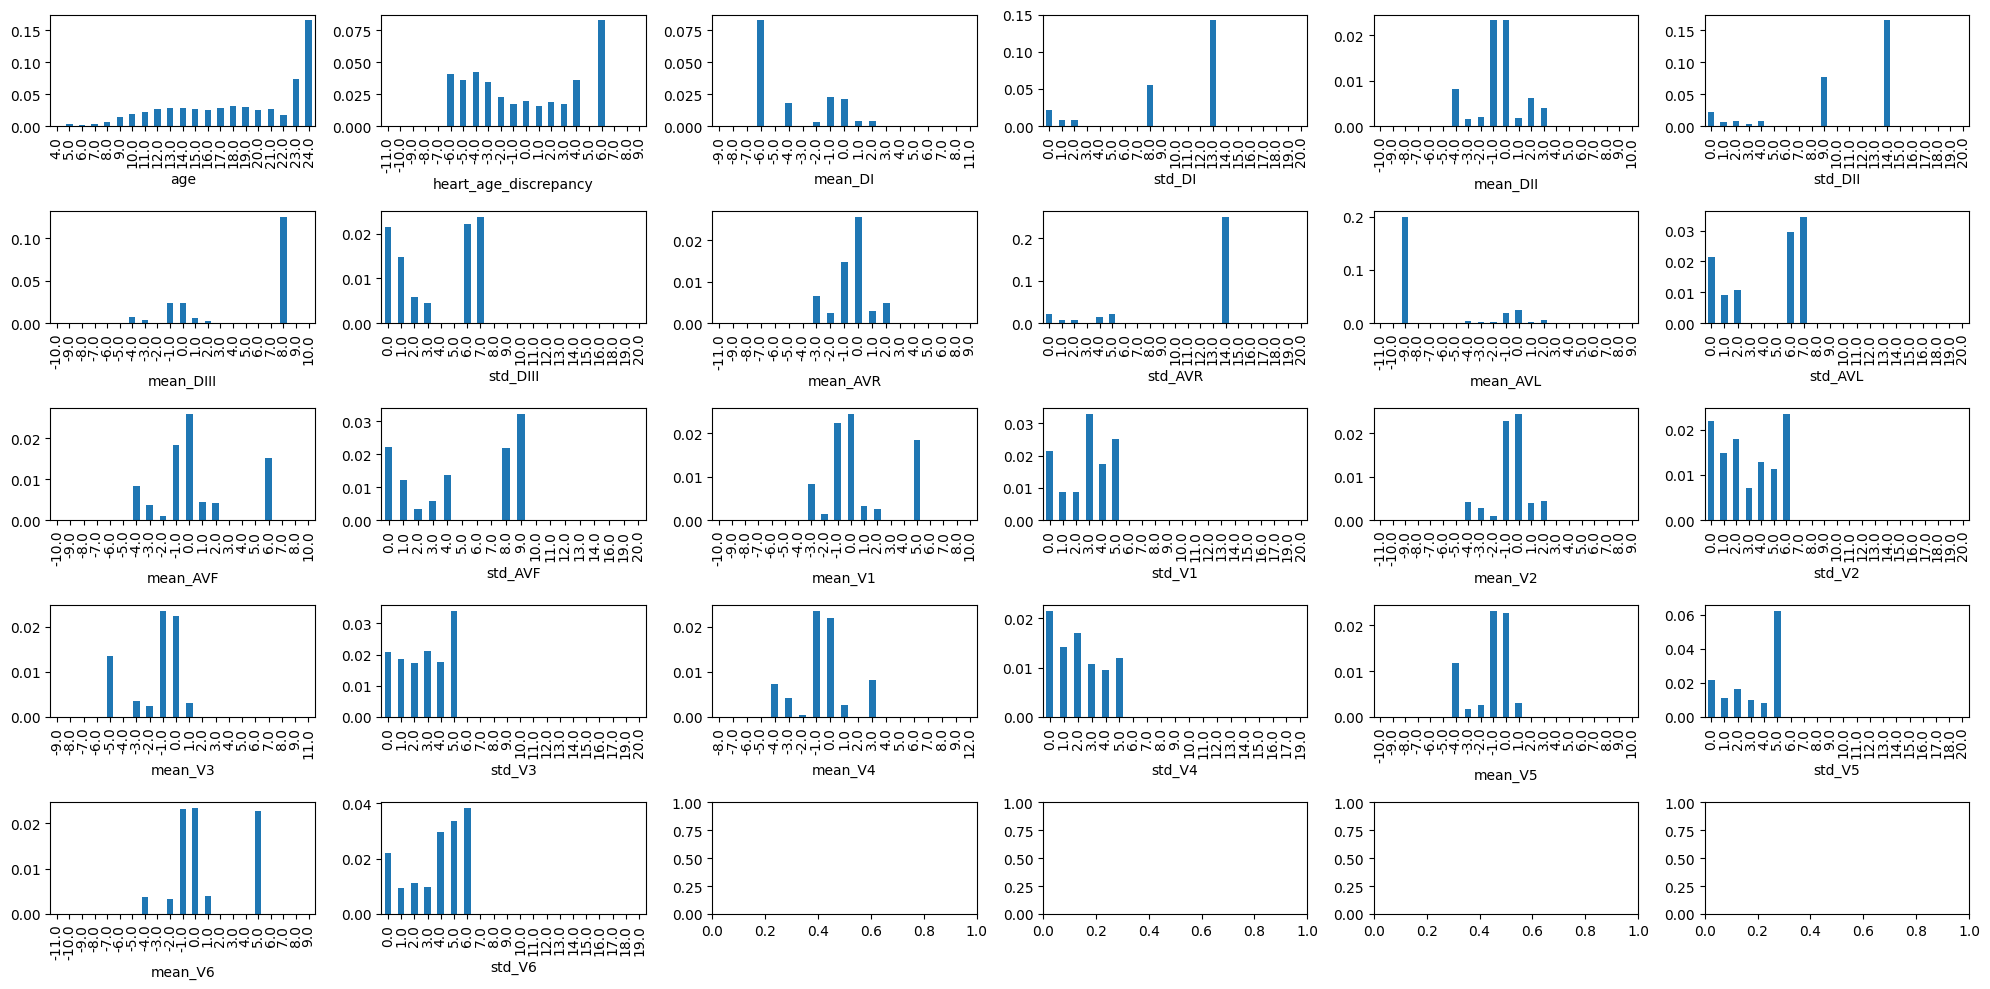

In [13]:
_, axes = plt.subplots(nrows=5, ncols=int(np.ceil(len(num_cols)//4)), figsize=(20,10))
for ax, cname in zip(axes.ravel(), num_cols):
    bin_size = (df[cname].max() - df[cname].min()) / 20
    df['label'].groupby(df[cname] // bin_size).mean().plot.bar(ax=ax)
plt.tight_layout()

In [23]:
plt.figure(figsize=(27,12))
sn.heatmap(df.drop(columns=factor_cols).corr(method='pearson', numeric_only=True), annot=True, vmin=-1, vmax=1, cmap='RdBu')
plt.tight_layout()

NameError: name 'df' is not defined

<Figure size 2700x1200 with 0 Axes>

In [24]:
from sklearn.preprocessing import MinMaxScaler


clean_df = df.drop(columns=factor_cols + ['RBBB'])

X, y = clean_df.drop(columns='label'), clean_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

NameError: name 'df' is not defined

In [73]:
base_est = LogisticRegression(penalty='l2', solver='lbfgs')
param_grid={'C': 1. / np.linspace(1e-1, 1e4, 100)}
gscv = GridSearchCV(base_est, param_grid=param_grid, scoring='roc_auc')
gscv.fit(X_train, y_train)
lr, lr_params = gscv.best_estimator_, gscv.best_params_

In [74]:



lr_score_cv, lr_score_test = gscv.best_score_, roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
print(f'AUC score for C={lr_params["C"]:.2f}: {lr_score_cv:.2f} (cross-validation), {lr_score_test:.2f} (test)')

AUC score for C=10.00: 0.74 (cross-validation), 0.70 (test)


<Axes: >

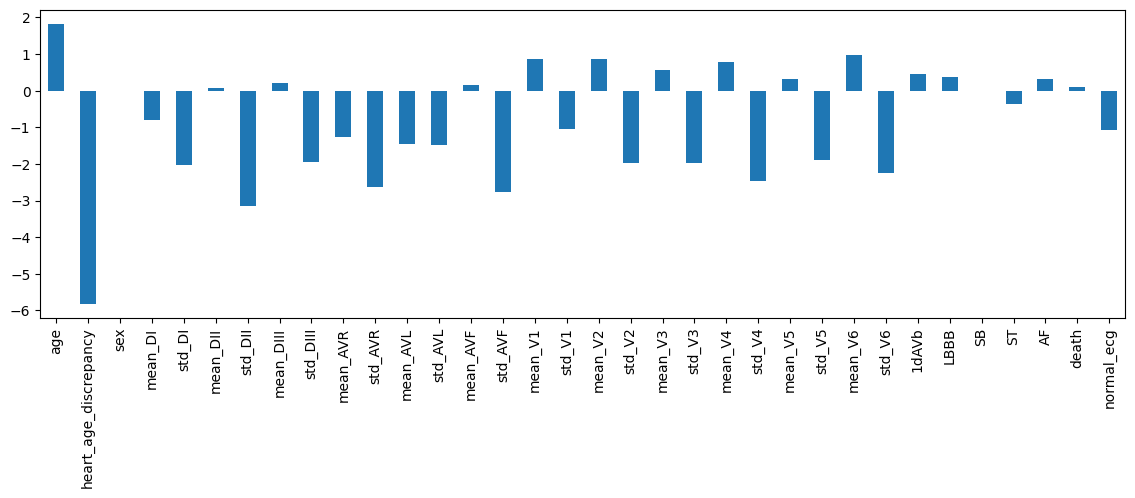

In [75]:
lr_coefs = pd.Series(index=X.columns, data=lr.coef_[0])
lr_coefs.plot(kind='bar', figsize=figsize)

In [31]:
import xgboost
base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain')
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv = GridSearchCV(base_est, param_grid=param_grid)
gscv.fit(X_train, y_train)
xbm, xbm_params = gscv.best_estimator_, gscv.best_params_

<Axes: >

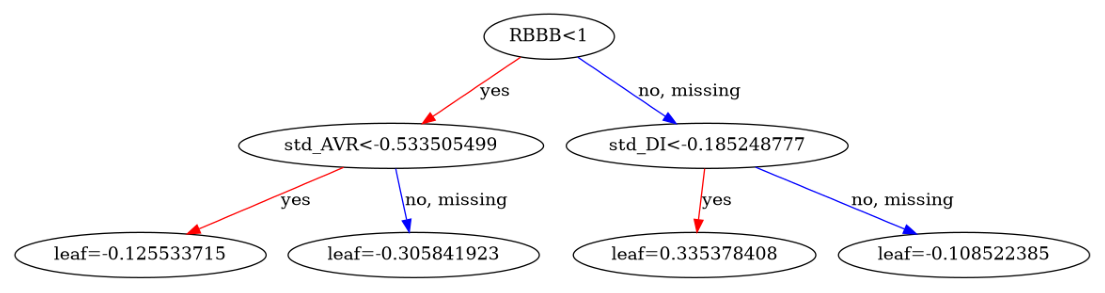

In [32]:
plt.figure(figsize=figsize)
xgboost.plot_tree(xbm, ax=plt.gca(), num_trees=0)

In [35]:
xbm_score_cv, xbm_score_test = gscv.best_score_, roc_auc_score(y_test, xbm.predict(X_test))
print(f'AUC score for {xbm_params}: {xbm_score_cv:.2f} (cross-val.), {xbm_score_test:.2f} (test)')

AUC score for {'max_depth': 2, 'n_estimators': 20, 'reg_lambda': np.float64(0.0)}: 0.98 (cross-val.), 0.50 (test)


<Axes: >

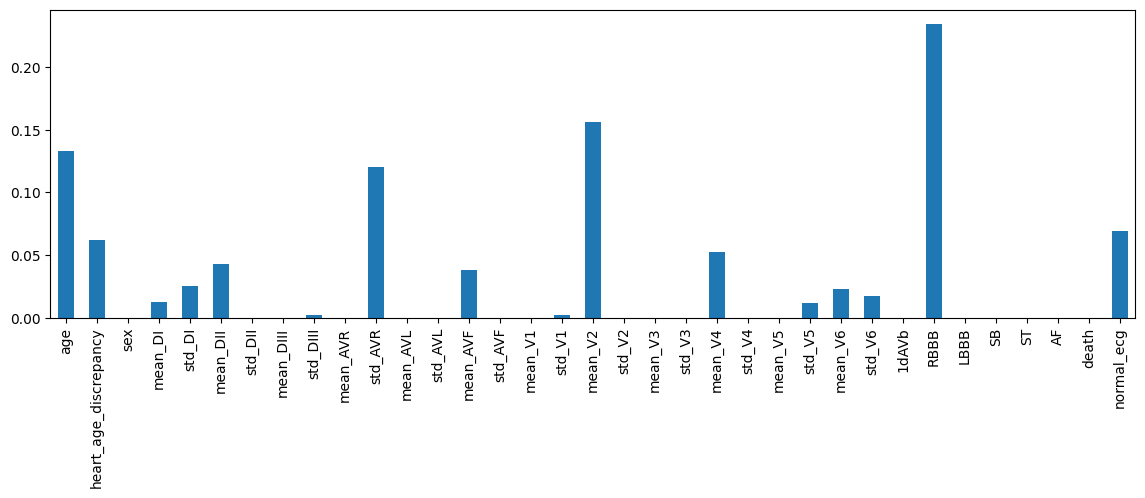

In [36]:
xbm_imp = pd.Series(index=X.columns, data=xbm.feature_importances_)
xbm_imp.plot(kind='bar', figsize=figsize)

/tmp/ipykernel_47219/3116684602.py:4: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


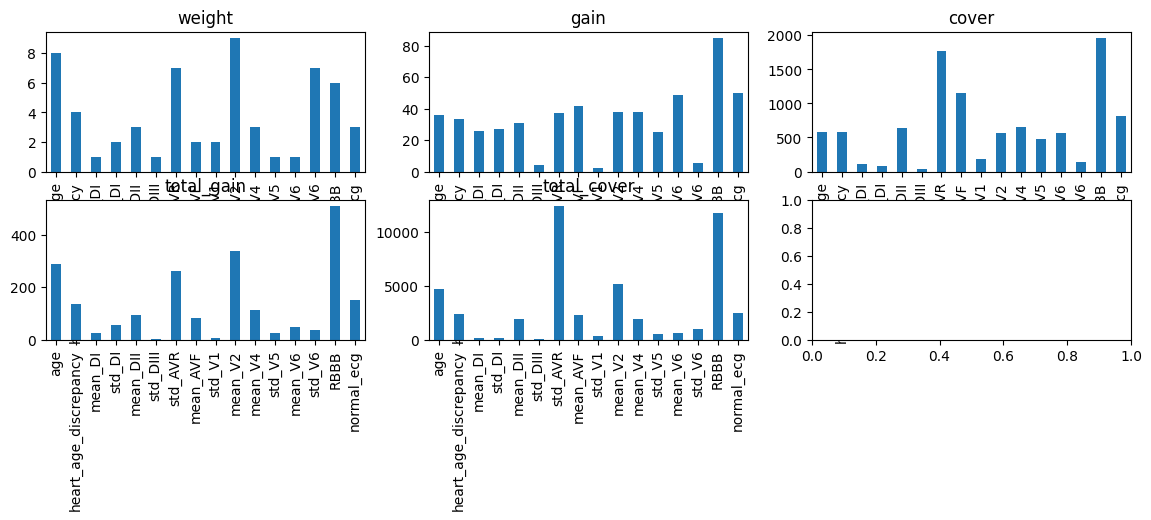

In [37]:
_, axes = plt.subplots(nrows=2, ncols=3, figsize=figsize)
for ax, imp_type in zip(axes.ravel(), ['weight', 'gain', 'cover', 'total_gain', 'total_cover']):
    pd.Series(xbm.get_booster().get_score(importance_type=imp_type)).plot.bar(ax=ax, title=imp_type)
plt.tight_layout()

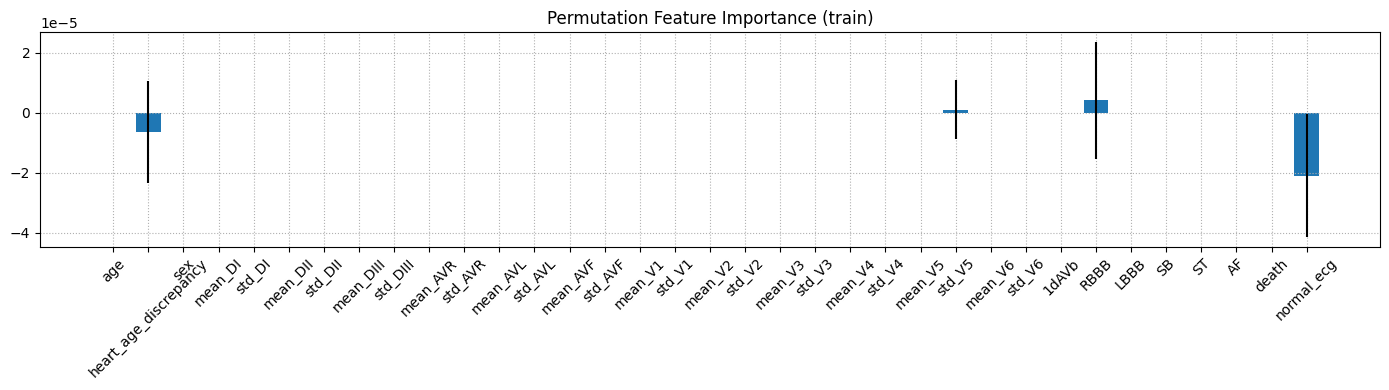

In [46]:
r_train = permutation_importance(xbm, X_train, y_train, n_repeats=30, random_state=42)
xbm_p_imp = pd.Series(index=X.columns, data=r_train.importances_mean)
util.plot_bars(xbm_p_imp, figsize=figsize, std=r_train.importances_std, title='Permutation Feature Importance (train)')

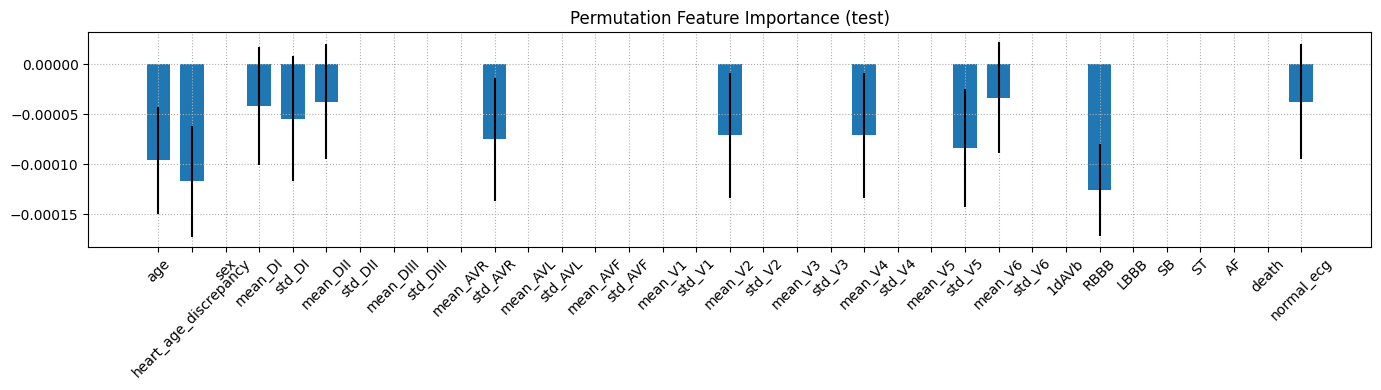

In [47]:
r_test = permutation_importance(xbm, X_test, y_test, n_repeats=30, random_state=42)
xbm_p_imp = pd.Series(index=X.columns, data=r_test.importances_mean)
util.plot_bars(xbm_p_imp, figsize=figsize, std=r_test.importances_std, title='Permutation Feature Importance (test)')

In [51]:
f = lambda x: xbm.predict_proba(x)[:,1]
explainer = shap.KernelExplainer(f, shap.sample(X_train, 10), link='logit')
shap_values = explainer(X_test)

  0%|          | 0/7960 [00:00<?, ?it/s]

  1%|          | 57/7960 [00:17<40:10,  3.28it/s]


KeyboardInterrupt: 

In [53]:
bfs = BorutaPy(xbm, n_estimators='auto', max_iter=100, verbose=0, random_state=42)
bfs.fit(X=X, y=y)

In [54]:
print('Confirmed important:', X.columns[bfs.ranking_ == 1].values)
print('Uncomfirmed:', X.columns[bfs.ranking_ == 2].values)
print('Confirmed unimportant:', X.columns[bfs.ranking_ > 2].values)

Confirmed important: ['age' 'heart_age_discrepancy' 'std_AVR' 'mean_AVF' 'mean_V2' 'mean_V4'
 'RBBB' 'normal_ecg']
Uncomfirmed: ['std_V5']
Confirmed unimportant: ['sex' 'mean_DI' 'std_DI' 'mean_DII' 'std_DII' 'mean_DIII' 'std_DIII'
 'mean_AVR' 'mean_AVL' 'std_AVL' 'std_AVF' 'mean_V1' 'std_V1' 'std_V2'
 'mean_V3' 'std_V3' 'std_V4' 'mean_V5' 'mean_V6' 'std_V6' '1dAVb' 'LBBB'
 'SB' 'ST' 'AF' 'death']
